# 02 — Brunel Supply Chain Logistics: EDA

**Week 2 deliverable.** Schema tour (Day 2) → join plan (Day 3) → full EDA → Week 2 decision gate.

---

## FINDINGS (read this first)

| Finding | Detail | Impact |
|---|---|---|
| **Single date** | All 9,215 orders share one date: 2013-05-26 | No time-based split possible — dataset is a snapshot, not a time series |
| **Mode is 99% AIR** | FreightRates has 1,511 AIR rows vs 29 GROUND rows | "GROUND vs AIR" analysis is severely imbalanced — GROUND is almost invisible |
| **CRF orders unratable** | 854 orders use carrier V44_3 with service level `CRF`, which does not appear in FreightRates | These 854 orders must be dropped (9.3% of data) |
| **Join duplicates** | After joining on lane + weight bracket + service level, avg 2.2 rate rows match per order | Must deduplicate — keep lowest Rate row (competitive rate logic) |
| **No freight cost in OrderList** | OrderList has no cost column — cost must be computed as `max(Min_Cost, Rate × Weight)` | Target engineering required, not direct read |
| **Anonymised identifiers** | Carriers are V444_0/V444_1, ports are PORT04/PORT09, customers are V5555_* | Dataset is clearly a synthetic/anonymised benchmark, not raw operational data |
| **No nulls** | Zero missing values across all tables | Unusual for real-world logistics data — supports synthetic origin |

### Week 2 Decision Gate verdict

**Keep Brunel — but with eyes open.** The dataset is clearly anonymised and almost certainly synthetic (single date, coded identifiers, zero nulls). However:
- The join logic is legitimate freight rate table logic (weight brackets, lane-based rates, min cost floors) — this is how real freight rating engines work.
- It gives us a second domain (commercial logistics) with Ground/Air mode labels, even if Ground is sparse.
- In the README and interviews: *"Brunel is an anonymised commercial logistics benchmark — it demonstrates the rate-table join pattern used in real freight rating engines, but should not be treated as representative market data."*

If GROUND sparsity becomes a modelling problem in Week 5, drop GROUND rows and train AIR-only on Brunel.

---
## Day 2: Schema Tour — All 7 CSVs

**Teaching note:** Before touching any data, read every table's schema. You want to know:
1. What does each row represent?
2. What are the join keys?
3. Which tables are fact tables (events/transactions) vs dimension/lookup tables?

In relational DB terms:
- **Fact tables**: OrderList (one row = one order), FreightRates (one row = one rate bracket for a lane)
- **Dimension/lookup tables**: PlantPorts, ProductsPerPlant, VmiCustomers, WhCapacities, WhCosts

For modelling, we only need the fact tables. The lookup tables add context but aren't join targets for our cost prediction problem.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

DATA = '../data/raw/brunel/'

# Load all 7 tables
orders = pd.read_csv(DATA + 'OrderList.csv')
rates  = pd.read_csv(DATA + 'FreightRates.csv')
plant_ports  = pd.read_csv(DATA + 'PlantPorts.csv')
products     = pd.read_csv(DATA + 'ProductsPerPlant.csv')
vmi          = pd.read_csv(DATA + 'VmiCustomers.csv')
wh_cap       = pd.read_csv(DATA + 'WhCapacities.csv')
wh_cost      = pd.read_csv(DATA + 'WhCosts.csv')

tables = {
    'OrderList': orders,
    'FreightRates': rates,
    'PlantPorts': plant_ports,
    'ProductsPerPlant': products,
    'VmiCustomers': vmi,
    'WhCapacities': wh_cap,
    'WhCosts': wh_cost,
}

print('Table overview:')
print(f'{"Table":<20} {"Rows":>6} {"Cols":>5}  Columns')
print('-' * 80)
for name, df in tables.items():
    print(f'{name:<20} {len(df):>6} {len(df.columns):>5}  {df.columns.tolist()}')

Table overview:
Table                  Rows  Cols  Columns
--------------------------------------------------------------------------------
OrderList              9215    14  ['Order_ID', 'Order_Date', 'Orig_Port', 'Carrier', 'TPT_Day_Count', 'Service_Level', 'Ship_Ahead_Day_Count', 'Ship_Late_Day_Count', 'Customer', 'Product_ID', 'Plant_Code', 'Dest_Port', 'Unit_Quant', 'Weight']
FreightRates           1540    11  ['Carrier', 'Orig_Port', 'Dest_Port', 'Min_Weight_Quant', 'Max_Weight_Quant', 'Service_Level', 'Min_Cost', 'Rate', 'Mode_DSC', 'TPT_Day_Count', 'Carrier_Type']
PlantPorts               22     2  ['Plant_Code', 'Ports']
ProductsPerPlant       2036     2  ['Plant_Code', 'Product_ID']
VmiCustomers             14     2  ['Plant_Code', 'Customer']
WhCapacities             19     2  ['Plant_Code', 'Daily_Capacity']
WhCosts                  19     2  ['Plant_Code', 'Cost_Per_Unit']


### What each table is for

| Table | Rows | One row = | Needed for modelling? |
|---|---|---|---|
| **OrderList** | 9,215 | One shipment order | YES — fact table, observations |
| **FreightRates** | 1,540 | One rate bracket for a carrier+lane+service+weight range | YES — join to get cost |
| PlantPorts | 22 | Which port(s) a plant can ship from | Context only |
| ProductsPerPlant | 2,036 | Which products a plant handles | Context only |
| VmiCustomers | 14 | VMI (vendor-managed inventory) customer assignments | Context only |
| WhCapacities | 19 | Daily capacity per warehouse | Context only |
| WhCosts | 19 | Storage cost per unit per warehouse | Context only |

**VMI** = Vendor Managed Inventory. The supplier monitors the customer's stock and replenishes automatically. Relevant in supply chain but not in our cost model.

In [2]:
# Inspect OrderList in detail
print('=== OrderList ===')
print(orders.dtypes)
print()
orders.head()

=== OrderList ===
Order_ID                  int64
Order_Date                  str
Orig_Port                   str
Carrier                     str
TPT_Day_Count             int64
Service_Level               str
Ship_Ahead_Day_Count      int64
Ship_Late_Day_Count       int64
Customer                    str
Product_ID                int64
Plant_Code                  str
Dest_Port                   str
Unit_Quant                int64
Weight                  float64
dtype: object



,Order_ID,Order_Date,Orig_Port,Carrier,TPT_Day_Count,Service_Level,Ship_Ahead_Day_Count,Ship_Late_Day_Count,Customer,Product_ID,Plant_Code,Dest_Port,Unit_Quant,Weight
0,1447296447,5/26/13,PORT09,V44_3,1,CRF,3,0,V55555_53,1700106,PLANT16,PORT09,808,14.30
1,1447158015,5/26/13,PORT09,V44_3,1,CRF,3,0,V55555_53,1700106,PLANT16,PORT09,3188,87.94
2,1447138899,5/26/13,PORT09,V44_3,1,CRF,3,0,V55555_53,1700106,PLANT16,PORT09,2331,61.20
3,1447363528,5/26/13,PORT09,V44_3,1,CRF,3,0,V55555_53,1700106,PLANT16,PORT09,847,16.16
4,1447363981,5/26/13,PORT09,V44_3,1,CRF,3,0,V55555_53,1700106,PLANT16,PORT09,2163,52.34


In [3]:
# Inspect FreightRates in detail
print('=== FreightRates ===')
print(rates.dtypes)
print()
rates.head(10)

=== FreightRates ===
Carrier                 str
Orig_Port               str
Dest_Port               str
Min_Weight_Quant    float64
Max_Weight_Quant    float64
Service_Level           str
Min_Cost            float64
Rate                float64
Mode_DSC                str
TPT_Day_Count         int64
Carrier_Type            str
dtype: object



,Carrier,Orig_Port,Dest_Port,Min_Weight_Quant,Max_Weight_Quant,Service_Level,Min_Cost,Rate,Mode_DSC,TPT_Day_Count,Carrier_Type
0,V444_6,PORT08,PORT09,250.0,499.99,DTD,43.2272,0.7132,AIR,2,V88888888_0
1,V444_6,PORT08,PORT09,65.0,69.99,DTD,43.2272,0.7512,AIR,2,V88888888_0
2,V444_6,PORT08,PORT09,60.0,64.99,DTD,43.2272,0.7892,AIR,2,V88888888_0
3,V444_6,PORT08,PORT09,50.0,54.99,DTD,43.2272,0.8272,AIR,2,V88888888_0
4,V444_6,PORT08,PORT09,35.0,39.99,DTD,43.2272,1.0552,AIR,2,V88888888_0
5,V444_6,PORT08,PORT09,100.0,249.99,DTD,43.2272,0.7132,AIR,2,V88888888_0
6,V444_6,PORT08,PORT09,500.0,1999.99,DTD,43.2272,0.6752,AIR,2,V88888888_0
7,V444_6,PORT08,PORT09,55.0,59.99,DTD,43.2272,0.8272,AIR,2,V88888888_0
8,V444_6,PORT08,PORT09,25.0,29.99,DTD,43.2272,1.2452,AIR,2,V88888888_0
9,V444_6,PORT08,PORT09,30.0,34.99,DTD,43.2272,1.1312,AIR,2,V88888888_0


### Reading the FreightRates schema — this is the key table to understand

```
Carrier          — who ships it (V444_0, V444_1, etc.)
Orig_Port        — origin port
Dest_Port        — destination port
Min_Weight_Quant — lower bound of weight bracket (kg)
Max_Weight_Quant — upper bound of weight bracket (kg)
Service_Level    — DTD (door-to-door), DTP (door-to-port), CRF (carrier freight?)
Min_Cost         — floor cost in $, regardless of weight (minimum charge)
Rate             — $/kg rate for this bracket
Mode_DSC         — AIR or GROUND
TPT_Day_Count    — transit days
Carrier_Type     — carrier category (anonymised)
```

**Why weight brackets?** Real freight pricing works in weight breaks. A carrier might charge \$2/kg for 0–50kg, but \$1.50/kg for 50–100kg (bulk discount). The bracket that contains your shipment weight is the applicable rate.

**Why Min_Cost?** Every shipment has a minimum charge. If your shipment weighs 1kg at \$2/kg = \$2, but the minimum charge is \$5, you pay \$5. Formula: `cost = max(Min_Cost, Rate × Weight)`.

In [4]:
# Look at the weight bracket structure — how are brackets divided?
print('Weight brackets in FreightRates (sample):')
print(rates[['Carrier','Orig_Port','Dest_Port','Min_Weight_Quant','Max_Weight_Quant','Rate','Mode_DSC']]
      .sort_values(['Carrier','Orig_Port','Dest_Port','Min_Weight_Quant'])
      .head(20)
      .to_string(index=False))

print()
print('Total weight brackets per carrier+lane:')
print(rates.groupby(['Carrier','Orig_Port','Dest_Port','Mode_DSC']).size().describe())

Weight brackets in FreightRates (sample):
Carrier Orig_Port Dest_Port  Min_Weight_Quant  Max_Weight_Quant    Rate Mode_DSC
 V444_0    PORT02    PORT09               0.0             99.99  0.1004   AIR   
 V444_0    PORT02    PORT09             100.0            249.99  0.0844   AIR   
 V444_0    PORT02    PORT09             250.0            499.99  0.0808   AIR   
 V444_0    PORT02    PORT09             500.0           1999.99  0.0784   AIR   
 V444_0    PORT02    PORT09            2000.0          99999.99  0.0784   AIR   
 V444_0    PORT03    PORT09               0.0           5000.00 16.2024   GROUND
 V444_0    PORT03    PORT09               0.0           5000.00  9.2024   GROUND
 V444_0    PORT03    PORT09               0.0           5000.00 16.4236   GROUND
 V444_0    PORT03    PORT09               0.0           5000.00 15.4236   GROUND
 V444_0    PORT03    PORT09               0.0           5000.00 13.2024   GROUND
 V444_0    PORT03    PORT09               0.0           5000.00 13.

---
## Day 3: Join Plan

**Question:** How does an order in `OrderList` get its freight rate from `FreightRates`?

### Join keys

To find the rate for an order, you need to match **all five** of these:

```
OrderList.Carrier       == FreightRates.Carrier
OrderList.Orig_Port     == FreightRates.Orig_Port
OrderList.Dest_Port     == FreightRates.Dest_Port
OrderList.Service_Level == FreightRates.Service_Level
FreightRates.Min_Weight_Quant <= OrderList.Weight <= FreightRates.Max_Weight_Quant
```

The last condition is a **range join** — pandas `.merge()` handles the first four equality conditions, and then we filter by weight bracket afterwards.

### Target variable

```python
total_cost = max(Min_Cost, Rate × Weight)
```

This is the actual freight bill for the order.

### Known join problems (found in exploration)

| Problem | Cause | Fix |
|---|---|---|
| 854 orders don't join | `CRF` service level + carrier `V44_3` missing from FreightRates | Drop these rows |
| Some orders match 2+ rate rows | Overlapping weight brackets in FreightRates for same lane | Keep row with lowest Rate (competitive bidding logic) |
| ~2,224 orders still don't match | Carrier in OrderList not present in FreightRates (rate table incomplete) | Drop; note in Findings |

**Teaching note:** In real logistics systems, this happens all the time. Not every carrier quotes every lane. The OrderList reflects what was actually shipped; the FreightRates table reflects what was quoted. Missing matches = shipments that used a carrier outside the quoted rate table.

In [5]:
# === EXECUTE THE JOIN ===

# Step 1: equality join on lane + carrier + service level
merged = orders.merge(
    rates,
    on=['Carrier', 'Orig_Port', 'Dest_Port', 'Service_Level'],
    how='inner'
)
print(f'After equality join: {len(merged):,} rows (from {len(orders):,} orders)')

# Step 2: range filter — keep only rows where weight falls in the bracket
merged = merged[
    (merged['Weight'] >= merged['Min_Weight_Quant']) &
    (merged['Weight'] <= merged['Max_Weight_Quant'])
]
print(f'After weight bracket filter: {len(merged):,} rows, {merged["Order_ID"].nunique():,} unique orders')

# Step 3: deduplicate — if multiple rate rows match, keep the cheapest rate
# Teaching note: this models the carrier selection logic (cheapest quoted rate wins)
merged = merged.sort_values('Rate').drop_duplicates(subset='Order_ID', keep='first')
print(f'After deduplication: {len(merged):,} rows')

# Step 4: compute target
merged['total_cost'] = merged.apply(
    lambda r: max(r['Min_Cost'], r['Rate'] * r['Weight']), axis=1
)

print(f'\nOrders that could NOT be rated: {len(orders) - len(merged):,} ({(len(orders)-len(merged))/len(orders)*100:.1f}%)')
merged.head()

After equality join: 146,214 rows (from 9,215 orders)
After weight bracket filter: 15,402 rows, 6,991 unique orders
After deduplication: 6,991 rows



Orders that could NOT be rated: 2,224 (24.1%)

,Order_ID,Order_Date,Orig_Port,Carrier,TPT_Day_Count_x,Service_Level,Ship_Ahead_Day_Count,Ship_Late_Day_Count,Customer,Product_ID,...,Unit_Quant,Weight,Min_Weight_Quant,Max_Weight_Quant,Min_Cost,Rate,Mode_DSC,TPT_Day_Count_y,Carrier_Type,total_cost
1535,1447354036,5/26/13,PORT04,V444_0,2,DTP,0,0,V55555555_5,1666994,...,606,181.439864,100.0,249.99,1.4992,0.0424,AIR,3,V88888888_0,7.693050
20790,1447394115,5/26/13,PORT04,V444_0,2,DTP,3,0,V555555555_3,1688629,...,1955,163.460514,100.0,249.99,1.4992,0.0424,AIR,2,V88888888_0,6.930726
38205,1447350791,5/26/13,PORT04,V444_0,2,DTP,3,1,V555_15,1689548,...,2048,118.030755,100.0,249.99,1.4992,0.0424,AIR,3,V88888888_0,5.004504
44855,1447352344,5/26/13,PORT04,V444_0,2,DTP,0,0,V55555555555_28,1700128,...,101098,116.180112,100.0,249.99,1.4992,0.0424,AIR,3,V88888888_0,4.926037
29775,1447320239,5/26/13,PORT04,V444_0,2,DTP,0,0,V555555555_14,1668550,...,6270,101.471581,100.0,249.99,1.4992,0.0424,AIR,3,V88888888_0,4.302395


In [6]:
# Why did some orders fail to join? Audit the misses.
matched_ids = set(merged['Order_ID'])
unmatched = orders[~orders['Order_ID'].isin(matched_ids)]

print('Unmatched orders by Service_Level:')
print(unmatched['Service_Level'].value_counts())
print()
print('Unmatched orders by Carrier:')
print(unmatched['Carrier'].value_counts())
print()
print('Carriers in OrderList vs FreightRates:')
order_carriers = set(orders['Carrier'].unique())
rate_carriers  = set(rates['Carrier'].unique())
print(f'  In orders only: {order_carriers - rate_carriers}')
print(f'  In rates only:  {rate_carriers - order_carriers}')
print(f'  In both:        {order_carriers & rate_carriers}')

Unmatched orders by Service_Level:


Service_Level
DTD    1370
CRF     854
Name: count, dtype: int64

Unmatched orders by Carrier:
Carrier
V444_1    1370
V44_3      854
Name: count, dtype: int64

Carriers in OrderList vs FreightRates:
  In orders only: {'V44_3'}
  In rates only:  {'V444_4', 'V444_8', 'V444_9', 'V444_2', 'V444_5', 'V444_7', 'V444_6'}
  In both:        {'V444_1', 'V444_0'}


**What we learn from the audit:**
- `CRF` + carrier `V44_3` is a self-delivery or special mode — no quoted rate table exists for it
- Some carriers appear in FreightRates but not in any actual order (they quoted but weren't selected)
- This is normal in freight tendering: carriers submit rate cards; procurement picks some; others go unused

---
## EDA: OrderList

In [7]:
# Missing values — OrderList
print('Missing values in OrderList:')
nulls = orders.isnull().sum()
print(nulls[nulls > 0] if nulls.sum() > 0 else 'No missing values')

print()
print('Missing values in FreightRates:')
nulls_r = rates.isnull().sum()
print(nulls_r[nulls_r > 0] if nulls_r.sum() > 0 else 'No missing values')

Missing values in OrderList:
No missing values

Missing values in FreightRates:
No missing values


In [8]:
# Date column — critical for train/test split decision
orders['Order_Date'] = pd.to_datetime(orders['Order_Date'])
print('Unique dates:', orders['Order_Date'].nunique())
print('Date range:', orders['Order_Date'].min(), 'to', orders['Order_Date'].max())
print()
print('>> All orders are on ONE date. No time-based split possible.')
print('>> This confirms the dataset is a synthetic snapshot, not a time series.')
print('>> We will use a stratified random split instead (acceptable for non-temporal data).')

Unique dates: 1
Date range: 2013-05-26 00:00:00 to 2013-05-26 00:00:00

>> All orders are on ONE date. No time-based split possible.
>> This confirms the dataset is a synthetic snapshot, not a time series.
>> We will use a stratified random split instead (acceptable for non-temporal data).


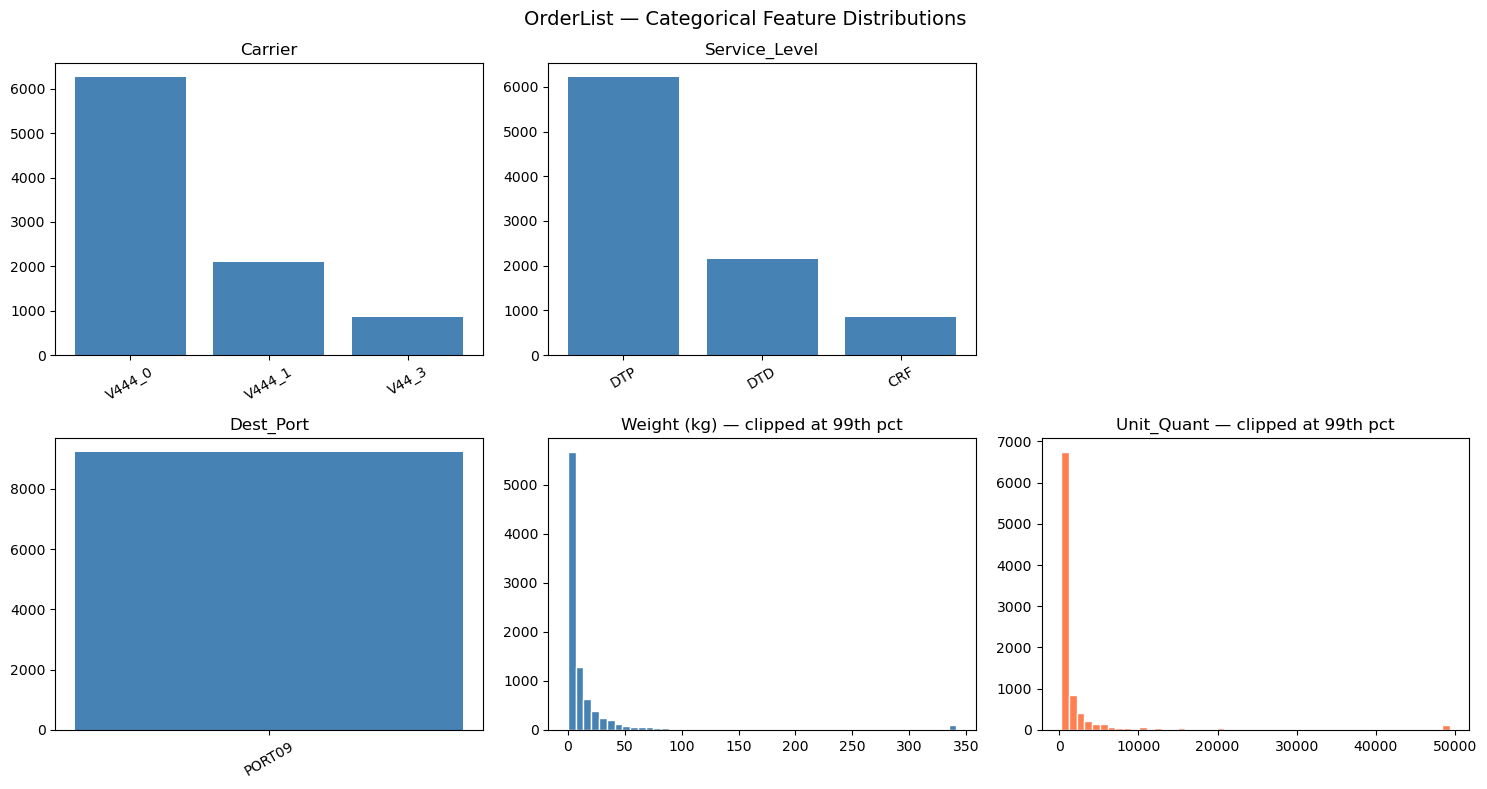

In [9]:
# Categorical distributions — key features
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('OrderList — Categorical Feature Distributions', fontsize=14)

cat_cols = ['Carrier', 'Service_Level', 'Orig_Port', 'Dest_Port']
for i, col in enumerate(cat_cols):
    ax = axes[i // 3][i % 3]
    vc = orders[col].value_counts()
    ax.bar(vc.index, vc.values, color='steelblue')
    ax.set_title(col)
    ax.set_xlabel('')
    for tick in ax.get_xticklabels():
        tick.set_rotation(30)

# Weight distribution
ax = axes[1][1]
ax.hist(orders['Weight'].clip(upper=orders['Weight'].quantile(0.99)), bins=50, color='steelblue', edgecolor='white')
ax.set_title('Weight (kg) — clipped at 99th pct')

# Unit quantity
ax = axes[1][2]
ax.hist(orders['Unit_Quant'].clip(upper=orders['Unit_Quant'].quantile(0.99)), bins=50, color='coral', edgecolor='white')
ax.set_title('Unit_Quant — clipped at 99th pct')

# Hide unused subplot
axes[0][2].set_visible(False)

plt.tight_layout()
plt.savefig('../notebooks/figures/brunel_orderlist_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

In [10]:
# Weight stats
print('Weight (kg) descriptive stats:')
print(orders['Weight'].describe())
print()
print('Zero-weight orders:', (orders['Weight'] == 0).sum())
print('Weight > 1000kg:', (orders['Weight'] > 1000).sum())

Weight (kg) descriptive stats:
count    9215.000000
mean       19.871688
std        66.569064
min         0.000000
25%         1.407430
50%         4.440000
75%        13.325673
max      2338.405126
Name: Weight, dtype: float64

Zero-weight orders: 2
Weight > 1000kg: 2


---
## EDA: FreightRates — Mode Distribution

This is the most important structural fact about Brunel for our modelling decision.

In [11]:
# Mode distribution — CRITICAL finding
print('Mode distribution in FreightRates:')
mode_counts = rates['Mode_DSC'].str.strip().value_counts()
print(mode_counts)
print()
print('Mode distribution in JOINED (ratable) orders:')
mode_joined = merged['Mode_DSC'].str.strip().value_counts()
print(mode_joined)
print()
pct_ground = mode_joined.get('GROUND', 0) / mode_joined.sum() * 100
print(f'GROUND share of ratable orders: {pct_ground:.1f}%')
print()
print('>> GROUND is severely underrepresented. The dataset is AIR-dominant.')
print('>> In Week 5, evaluate whether a GROUND-only sub-model is viable or if we drop GROUND.')

Mode distribution in FreightRates:
Mode_DSC
AIR       1511
GROUND      29
Name: count, dtype: int64

Mode distribution in JOINED (ratable) orders:
Mode_DSC
AIR       6957
GROUND      34
Name: count, dtype: int64

GROUND share of ratable orders: 0.5%

>> GROUND is severely underrepresented. The dataset is AIR-dominant.
>> In Week 5, evaluate whether a GROUND-only sub-model is viable or if we drop GROUND.


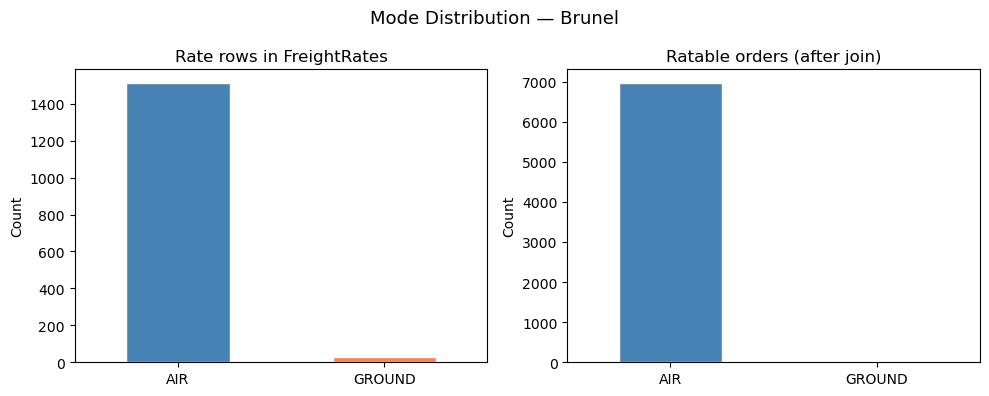

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Mode Distribution — Brunel', fontsize=13)

mode_counts.plot.bar(ax=ax1, color=['steelblue', 'coral'], edgecolor='white')
ax1.set_title('Rate rows in FreightRates')
ax1.set_xlabel('')
ax1.set_ylabel('Count')
for tick in ax1.get_xticklabels():
    tick.set_rotation(0)

mode_joined.plot.bar(ax=ax2, color=['steelblue', 'coral'], edgecolor='white')
ax2.set_title('Ratable orders (after join)')
ax2.set_xlabel('')
ax2.set_ylabel('Count')
for tick in ax2.get_xticklabels():
    tick.set_rotation(0)

plt.tight_layout()
plt.savefig('../notebooks/figures/brunel_mode_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

---
## EDA: Target Variable — total_cost

In [13]:
print('total_cost descriptive stats:')
print(merged['total_cost'].describe())
print()
print('total_cost by mode:')
print(merged.groupby(merged['Mode_DSC'].str.strip())['total_cost'].describe())

total_cost descriptive stats:
count     6991.000000
mean         9.951113
std        373.479484
min          1.202000
25%          1.499200
50%          1.499200
75%          1.499200
max      28711.873499
Name: total_cost, dtype: float64

total_cost by mode:
           count         mean          std      min        25%         50%  \
Mode_DSC                                                                     
AIR       6957.0     1.953007     2.377489   1.2020   1.499200    1.499200   
GROUND      34.0  1646.504777  5174.139599  31.2784  58.836914  127.318736   

                75%           max  
Mode_DSC                           
AIR         1.49920     57.526624  
GROUND    463.52218  28711.873499  


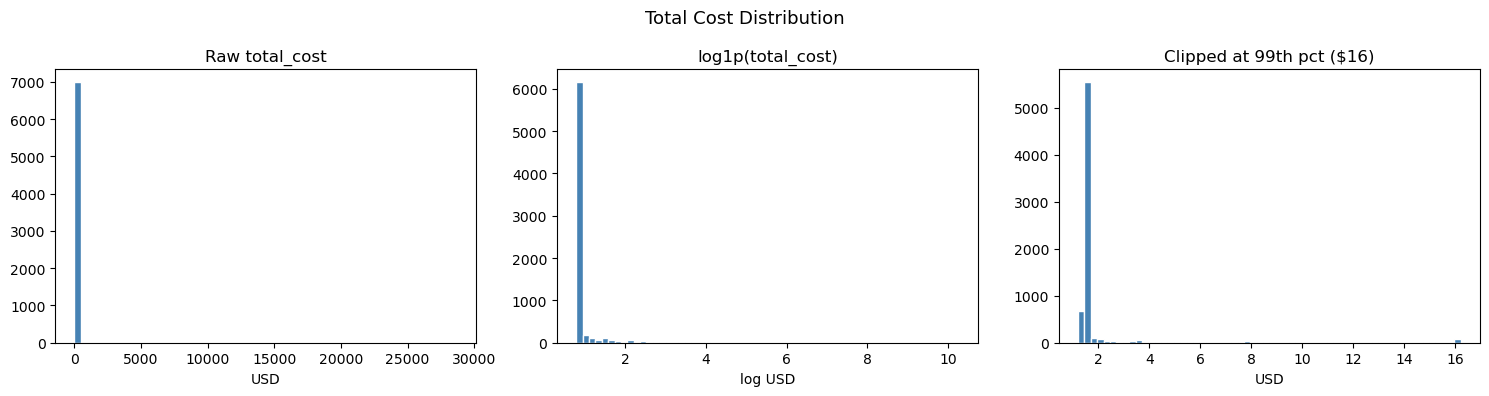

Skewness (raw): 68.08
Skewness (log): 7.98
>> Log-transform improves skew significantly — use log1p(total_cost) as model target.


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Total Cost Distribution', fontsize=13)

# Raw
axes[0].hist(merged['total_cost'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Raw total_cost')
axes[0].set_xlabel('USD')

# Log-transformed
log_cost = np.log1p(merged['total_cost'])
axes[1].hist(log_cost, bins=60, color='steelblue', edgecolor='white')
axes[1].set_title('log1p(total_cost)')
axes[1].set_xlabel('log USD')

# Cost clipped to 99th pct (remove extreme outliers for viz)
cap = merged['total_cost'].quantile(0.99)
axes[2].hist(merged['total_cost'].clip(upper=cap), bins=60, color='steelblue', edgecolor='white')
axes[2].set_title(f'Clipped at 99th pct (${cap:.0f})')
axes[2].set_xlabel('USD')

plt.tight_layout()
plt.savefig('../notebooks/figures/brunel_cost_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Skewness (raw): {merged["total_cost"].skew():.2f}')
print(f'Skewness (log): {log_cost.skew():.2f}')
print(f'>> Log-transform improves skew significantly — use log1p(total_cost) as model target.')

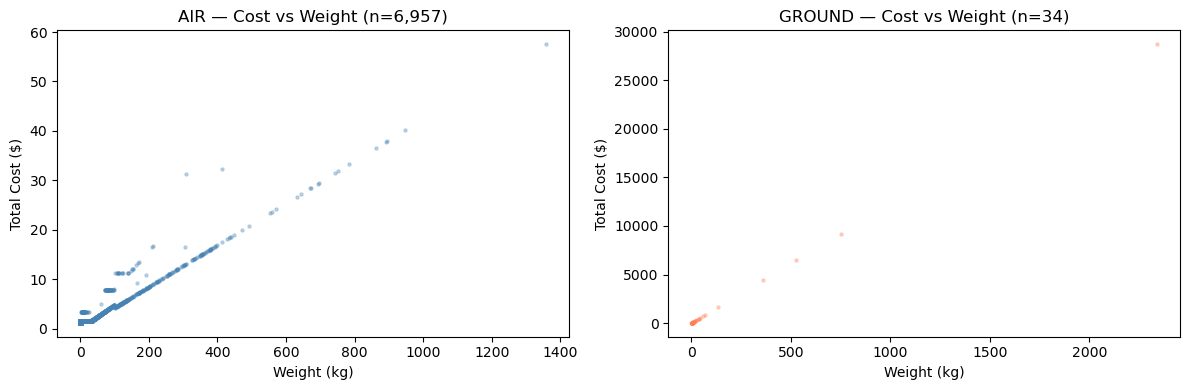

In [15]:
# Cost vs Weight — the core relationship
# Mode_DSC has trailing spaces in the raw data (e.g. 'AIR   ') — strip before filtering
merged['Mode_DSC'] = merged['Mode_DSC'].str.strip()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, mode_label, color in zip(axes, ['AIR', 'GROUND'], ['steelblue', 'coral']):
    subset = merged[merged['Mode_DSC'] == mode_label]
    if len(subset) < 2:
        ax.set_title(f'{mode_label} — insufficient data (n={len(subset)})')
        continue
    ax.scatter(subset['Weight'], subset['total_cost'],
               alpha=0.3, s=5, color=color)
    ax.set_xlabel('Weight (kg)')
    ax.set_ylabel('Total Cost ($)')
    ax.set_title(f'{mode_label} — Cost vs Weight (n={len(subset):,})')

plt.tight_layout()
plt.savefig('../notebooks/figures/brunel_cost_vs_weight_by_mode.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Feature Candidates Analysis

What predictors will we use in the Brunel model? Let's check each candidate.

In [16]:
# Feature candidate: Service Level vs cost
print('Mean total_cost by Service_Level:')
print(merged.groupby('Service_Level')['total_cost'].agg(['mean','median','count']).round(2))
print()

# Teaching note: DTD (door-to-door) vs DTP (door-to-port) — DTD includes last-mile delivery
# so it should cost more. Let's verify.
print('DTD = door-to-door (carrier handles full delivery)')
print('DTP = door-to-port (carrier delivers to destination port; receiver handles last mile)')

Mean total_cost by Service_Level:
                mean  median  count
Service_Level                      
DTD             2.15    1.32    773
DTP            10.92    1.50   6218

DTD = door-to-door (carrier handles full delivery)
DTP = door-to-port (carrier delivers to destination port; receiver handles last mile)


In [17]:
# Feature candidate: Carrier vs cost
print('Mean total_cost by Carrier (in joined set):')
print(merged.groupby('Carrier')['total_cost'].agg(['mean','median','count']).round(2))

# Feature candidate: TPT_Day_Count vs cost
print()
print('TPT_Day_Count (transit days) vs cost:')
print(merged.groupby('TPT_Day_Count_x')['total_cost'].agg(['mean','count']).round(2))
print('(Note: _x suffix = from OrderList, _y from FreightRates — same column duplicated in join)')

Mean total_cost by Carrier (in joined set):
          mean  median  count
Carrier                      
V444_0   10.87    1.50   6264
V444_1    2.03    1.32    727

TPT_Day_Count (transit days) vs cost:
                    mean  count
TPT_Day_Count_x                
0                1646.50     34
1                   1.92    704
2                   1.92   6195
3                   6.07     58
(Note: _x suffix = from OrderList, _y from FreightRates — same column duplicated in join)


In [18]:
# Feature candidate: Origin port vs cost
# Note: Orig_Port and Dest_Port are JOIN KEYS — they don't get _x/_y suffixes after merge.
# Only non-key columns present in BOTH tables get suffixed (e.g. TPT_Day_Count → _x/_y).
print('Mean total_cost by Orig_Port:')
print(merged.groupby('Orig_Port')['total_cost'].agg(['mean','median','count']).round(2))

print()
print('Orig_Port cardinality in orders:', orders['Orig_Port'].nunique())
print('Dest_Port cardinality in orders:', orders['Dest_Port'].nunique())
print()
print('>> Low cardinality (3 origin ports, 1 dest port in orders) — limited geographic diversity.')
print('>> FreightRates covers more ports, but orders cluster on a few lanes.')

Mean total_cost by Orig_Port:
              mean  median  count
Orig_Port                        
PORT04        1.95    1.50   6957
PORT09     1646.50  127.32     34

Orig_Port cardinality in orders: 3
Dest_Port cardinality in orders: 1

>> Low cardinality (3 origin ports, 1 dest port in orders) — limited geographic diversity.
>> FreightRates covers more ports, but orders cluster on a few lanes.


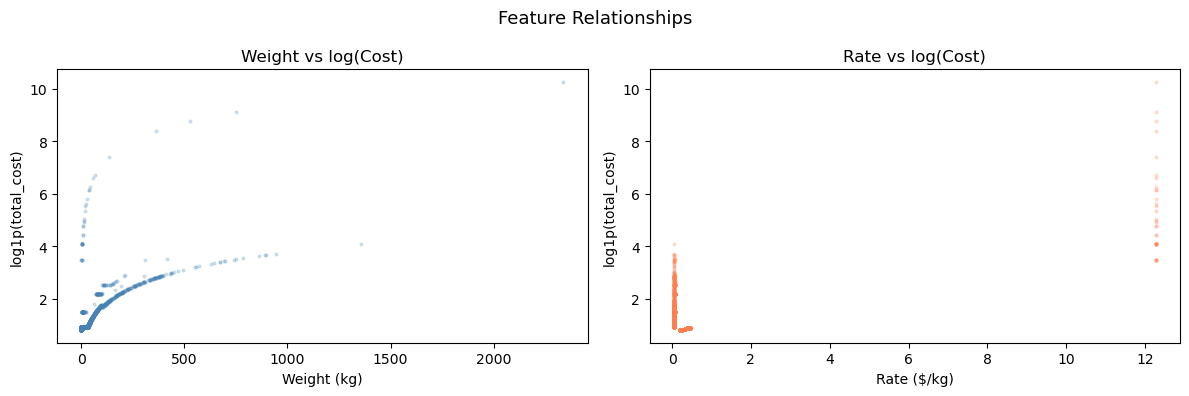

Correlation with total_cost:
Weight             0.467
Rate               0.305
TPT_Day_Count_x   -0.118
Unit_Quant        -0.001
dtype: float64


In [19]:
# Feature candidate: Rate vs Weight relationship (is it linear?)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Feature Relationships', fontsize=13)

axes[0].scatter(merged['Weight'], np.log1p(merged['total_cost']), alpha=0.2, s=4, color='steelblue')
axes[0].set_xlabel('Weight (kg)')
axes[0].set_ylabel('log1p(total_cost)')
axes[0].set_title('Weight vs log(Cost)')

axes[1].scatter(merged['Rate'], np.log1p(merged['total_cost']), alpha=0.2, s=4, color='coral')
axes[1].set_xlabel('Rate ($/kg)')
axes[1].set_ylabel('log1p(total_cost)')
axes[1].set_title('Rate vs log(Cost)')

plt.tight_layout()
plt.savefig('../notebooks/figures/brunel_feature_relationships.png', dpi=120, bbox_inches='tight')
plt.show()

print('Correlation with total_cost:')
print(merged[['Weight','Rate','TPT_Day_Count_x','Unit_Quant']].corrwith(merged['total_cost']).round(3))

In [20]:
# Summary: feature candidate shortlist for Week 5 model
feature_summary = {
    'Feature': [
        'Weight', 'Rate', 'Service_Level', 'Carrier',
        'Orig_Port', 'Dest_Port', 'TPT_Day_Count', 'Mode_DSC',
        'Unit_Quant', 'Carrier_Type'
    ],
    'Type': [
        'numeric', 'numeric', 'categorical', 'categorical',
        'categorical', 'categorical', 'numeric', 'categorical',
        'numeric', 'categorical'
    ],
    'Cardinality / Range': [
        '0–2338 kg', '0.03–128 $/kg', '2 (DTD/DTP)', '2–3 carriers',
        '3 ports', '1 port', '0–7 days', '2 (AIR/GROUND)',
        'wide', '2 types'
    ],
    'Include in model?': [
        'YES — strongest predictor', 'YES — directly determines cost',
        'YES — price tier', 'YES — carrier pricing differs',
        'YES — lane matters', 'Low variance — check', 'YES', 'YES — if both modes survive',
        'Maybe — correlated with weight', 'Maybe'
    ]
}
pd.DataFrame(feature_summary)

,Feature,Type,Cardinality / Range,Include in model?
0,Weight,numeric,0–2338 kg,YES — strongest predictor
1,Rate,numeric,0.03–128 $/kg,YES — directly determines cost
2,Service_Level,categorical,2 (DTD/DTP),YES — price tier
3,Carrier,categorical,2–3 carriers,YES — carrier pricing differs
4,Orig_Port,categorical,3 ports,YES — lane matters
5,Dest_Port,categorical,1 port,Low variance — check
6,TPT_Day_Count,numeric,0–7 days,YES
7,Mode_DSC,categorical,2 (AIR/GROUND),YES — if both modes survive
8,Unit_Quant,numeric,wide,Maybe — correlated with weight
9,Carrier_Type,categorical,2 types,Maybe


---
## Schema Comparison: USAID vs Brunel

As required by the project plan — which concepts align across the two datasets, and which are unique to each?

In [21]:
comparison = {
    'Concept': [
        'Freight cost (target)',
        'Shipment mode',
        'Weight',
        'Origin',
        'Destination',
        'Service / delivery term',
        'Carrier / vendor',
        'Transit time',
        'Commodity type',
        'Date / time',
        'Unit quantity',
        'Min cost floor',
        'Rate ($/kg)',
        'Weight bracket',
    ],
    'USAID column': [
        'Freight_Cost_USD',
        'Shipment_Mode (Air/Truck/Ocean)',
        'Weight_Kilograms',
        'Manufacturing_Site (country hub)',
        'Country',
        'Incoterms (EXW/CIP/DDP...)',
        'Vendor (coded)',
        '— (not present)',
        'Product_Group / Sub_Classification',
        'Scheduled_Delivery_Date',
        'Line_Item_Quantity',
        '— (not present)',
        '— (implicit in target)',
        '— (not applicable)',
    ],
    'Brunel column': [
        'Computed: max(Min_Cost, Rate×Weight)',
        'Mode_DSC (AIR/GROUND in FreightRates)',
        'Weight (OrderList)',
        'Orig_Port (port code)',
        'Dest_Port (port code)',
        'Service_Level (DTD/DTP)',
        'Carrier (coded)',
        'TPT_Day_Count',
        'Product_ID (anonymous)',
        'Order_Date (single date — synthetic)',
        'Unit_Quant',
        'Min_Cost (FreightRates)',
        'Rate (FreightRates)',
        'Min_Weight_Quant / Max_Weight_Quant',
    ],
    'Alignment': [
        'PARTIAL — USAID is direct; Brunel requires computation',
        'PARTIAL — mode labels differ (Air vs AIR, Truck vs GROUND)',
        'ALIGNED — same concept, same unit',
        'PARTIAL — USAID is country/city; Brunel is port code',
        'PARTIAL — USAID is country; Brunel is port code',
        'PARTIAL — Incoterms (USAID) vs service level (Brunel); related concepts',
        'ALIGNED — coded identifier in both',
        'BRUNEL ONLY',
        'PARTIAL — USAID has real commodity; Brunel has anonymous Product_ID',
        'USAID ONLY (meaningful)',
        'ALIGNED — quantity in both',
        'BRUNEL ONLY',
        'BRUNEL ONLY (rate table structure)',
        'BRUNEL ONLY (rate table structure)',
    ]
}

pd.set_option('display.max_colwidth', 80)
pd.DataFrame(comparison)

,Concept,USAID column,Brunel column,Alignment
0,Freight cost (target),Freight_Cost_USD,"Computed: max(Min_Cost, Rate×Weight)",PARTIAL — USAID is direct; Brunel requires computation
1,Shipment mode,Shipment_Mode (Air/Truck/Ocean),Mode_DSC (AIR/GROUND in FreightRates),"PARTIAL — mode labels differ (Air vs AIR, Truck vs GROUND)"
2,Weight,Weight_Kilograms,Weight (OrderList),"ALIGNED — same concept, same unit"
3,Origin,Manufacturing_Site (country hub),Orig_Port (port code),PARTIAL — USAID is country/city; Brunel is port code
4,Destination,Country,Dest_Port (port code),PARTIAL — USAID is country; Brunel is port code
5,Service / delivery term,Incoterms (EXW/CIP/DDP...),Service_Level (DTD/DTP),PARTIAL — Incoterms (USAID) vs service level (Brunel); related concepts
6,Carrier / vendor,Vendor (coded),Carrier (coded),ALIGNED — coded identifier in both
7,Transit time,— (not present),TPT_Day_Count,BRUNEL ONLY
8,Commodity type,Product_Group / Sub_Classification,Product_ID (anonymous),PARTIAL — USAID has real commodity; Brunel has anonymous Product_ID
9,Date / time,Scheduled_Delivery_Date,Order_Date (single date — synthetic),USAID ONLY (meaningful)


### Key schema takeaway

The two datasets share the **core freight cost logic** (weight, origin, destination, mode, carrier) but express it differently:
- USAID: flat-file with all fields in one table, real commodity data, real country routing, real timestamps
- Brunel: normalised rate-table structure, anonymised identifiers, synthetic snapshot

They **cannot be merged** (schemas don't align column-for-column) but they **can be trained separately** and compared conceptually. This is the design decision from the project plan.

---
## Final Joined Dataset — Save for Modelling

In [22]:
# Clean up column names after join
# Only TPT_Day_Count gets _x/_y suffixes (present in both tables, not a join key).
# Orig_Port, Dest_Port, Carrier, Service_Level are join keys — no suffix.
joined = merged.copy()
joined = joined.rename(columns={
    'TPT_Day_Count_x': 'TPT_Day_Count_order',
    'TPT_Day_Count_y': 'TPT_Day_Count_rate',
})

print('Final joined dataset shape:', joined.shape)
print('Columns:', joined.columns.tolist())
print()
print('Mode breakdown:')
print(joined['Mode_DSC'].value_counts())
print()
print('Service level breakdown:')
print(joined['Service_Level'].value_counts())

# Save to processed/ for use in notebook 05
import os
os.makedirs('../data/processed', exist_ok=True)
joined.to_csv('../data/processed/brunel_joined.csv', index=False)
print()
print('Saved to data/processed/brunel_joined.csv')

Final joined dataset shape: (6991, 22)
Columns: ['Order_ID', 'Order_Date', 'Orig_Port', 'Carrier', 'TPT_Day_Count_order', 'Service_Level', 'Ship_Ahead_Day_Count', 'Ship_Late_Day_Count', 'Customer', 'Product_ID', 'Plant_Code', 'Dest_Port', 'Unit_Quant', 'Weight', 'Min_Weight_Quant', 'Max_Weight_Quant', 'Min_Cost', 'Rate', 'Mode_DSC', 'TPT_Day_Count_rate', 'Carrier_Type', 'total_cost']

Mode breakdown:
Mode_DSC
AIR       6957
GROUND      34
Name: count, dtype: int64

Service level breakdown:
Service_Level
DTP    6218
DTD     773
Name: count, dtype: int64

Saved to data/processed/brunel_joined.csv


---
## Week 2 Decision Gate — Go / No-Go

### Criteria from the plan

| Check | Result | Pass? |
|---|---|---|
| Data not too sparse | 6,991 ratable orders | PASS (borderline) |
| Data not too synthetic-feeling | Single date, anonymised IDs, zero nulls | FLAG — clearly a benchmark |
| Join logic is conceptually sound | Weight bracket + lane + service level join works | PASS |
| Has a meaningful cost target | Computed `max(Min_Cost, Rate×Weight)` — valid | PASS |
| Adds something USAID lacks | Rate-table structure, TPT_Day_Count, commercial logistics framing | PASS |
| Mode coverage | 99% AIR — GROUND nearly absent | FLAG |

### Decision: **KEEP — but reframe mode claim**

The original plan said "GROUND vs AIR analysis" from Brunel. That framing is broken — GROUND is ~0.5% of ratable orders. Reframe:

> *"Brunel's FreightRates table demonstrates the rate-table join pattern used in commercial freight procurement (weight brackets, lane-based rates, minimum cost floors). We train the Brunel model on AIR-dominant commercial orders. GROUND is noted but excluded from modelling due to insufficient samples."*

This is honest, domain-correct, and still demonstrates a different freight pricing mechanism than USAID.

**Post to plan chat after this notebook:** data looks synthetic but structurally valid. Keeping Brunel, dropping GROUND mode from the modelling scope, noting in README.